# MDR-TS v8.2
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v8.2
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base_1.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Making a model to see how much of soil moisture variance rain explains

For other info see `MDR-TS-v1.0`

## 0. Imports

In [23]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.impute import SimpleImputer

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [136]:
# Project paths
VERSION = "v8"
SUBVERSION = "v8.2"
RUN_NAME = "mdr_ts_v8_2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v8/v8.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_3.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_3.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_3.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/train_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/val_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/test_derived_new.csv
train: dropped columns ['slope', 'elev']

train: shape=(16972, 352)
train: columns=352
val: dropped columns ['slope', 'elev']

val: shape=(2919, 352)
val: columns=352
test: dropped columns ['slope', 'elev']

test: shape=(2829, 352)
test: columns=352


In [73]:
# Dropping TouchNet because it has no rows in the validation split

DROP_STATION = "Touchet_WA_824"

def drop_station(df, station_id=DROP_STATION):
    before = len(df)
    out = df[df["station_id"] != station_id].copy()
    after = len(out)
    print(f"Dropped {station_id}: {before} -> {after} rows (-{before-after})")
    return out

train_df = drop_station(train_df)
val_df   = drop_station(val_df)
test_df  = drop_station(test_df)

Dropped Touchet_WA_824: 16972 -> 13661 rows (-3311)
Dropped Touchet_WA_824: 2919 -> 2919 rows (-0)
Dropped Touchet_WA_824: 2829 -> 2659 rows (-170)


In [74]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 355

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5', 'A_d_G_API_kobs7', 'A_d_G_API_kobs14']


## 4. Data Sanity Checks

In [75]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
  "precip_mm",

  "G_rain_sum_30d",

  "C_lag_E_SAR_diff_kobs12",
  "C_lag_E_SAR_diff_kobs30",
  "C_lag_E_SAR_ratio_kobs30",
  "C_lag_F_NDVI_kobs30",
  "C_lag_LST_modis_kobs12",
  "C_lag_LST_modis_kobs30",
  "DOY",
  "D_sa_E_SAR_ratio",
  "D_sa_F_NDMI",
  "D_z_E_SAR_ratio",
  "D_z_F_NDMI",
  "E_SAR_diff",
  "E_SAR_ratio",
  "F_MSI",
  "F_NDMI",
  "V_ema_LST_modis_kobs30",
  "V_rollmax_E_SAR_diff_kobs14",
  "V_rollmax_E_SAR_diff_kobs30",
  "V_rollmax_F_NDVI_kobs30",
  "V_rollmax_LST_modis_kobs7",
  "V_rollmax_s2_b11_kobs30",
  "V_rollmin_E_SAR_diff_kobs30",
  "V_rollmin_E_SAR_ratio_kobs30",
  "V_rollmin_F_NDMI_kobs30",
  "V_rollmin_s2_b11_kobs30",
  "V_rollmin_s2_b12_kobs30",
  "s1_vh",
  "s2_b8",
  "A_d_LST_modis_kobs7",
  "A_grad_LST_modis_kobs14",
  "C_lag_E_SAR_diff_kobs6",
  "V_rollmax_E_SAR_diff_kobs7",
  "V_rollmax_E_SAR_ratio_kobs14",
  "V_rollmax_F_NDVI_kobs14",
  "s2_b12",
  "D_sa_LST_modis"
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 38
  Target:   soil_moisture_5cm


In [76]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


---

### 4.1 Implementing the New Rain Features

In [77]:
RAIN_COL = "precip_mm"
RAIN_THR = 4.0     # from my analysis
K = 7              # 0..7 day short horizon
WEIGHTS = np.array([1.0, 0.6, 0.2, 0.1, 0.05, 0.02, 0.01, 0.0], dtype=float)  # len = K+1
NEW_FEATURES = [
    "rain_event_impulse_0_7",
    "rain_mm_impulse_0_7",
    "days_since_rain_event",
]

def add_rain_impulse_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d = d.sort_values(["station_id", "date"]).reset_index(drop=True)

    d["_rain_event"] = (d[RAIN_COL] >= RAIN_THR).astype(int)

    for k in range(0, K + 1):
        d[f"_ev_lag{k}"] = d.groupby("station_id")["_rain_event"].shift(k)
        d[f"_mm_lag{k}"] = d.groupby("station_id")[RAIN_COL].shift(k)

    ev_cols = [f"_ev_lag{k}" for k in range(0, K + 1)]
    mm_cols = [f"_mm_lag{k}" for k in range(0, K + 1)]

    ev_mat = d[ev_cols].fillna(0).to_numpy(dtype=float)
    mm_mat = d[mm_cols].fillna(0).to_numpy(dtype=float)

    d["rain_event_impulse_0_7"] = (ev_mat * WEIGHTS).sum(axis=1)
    d["rain_mm_impulse_0_7"]    = (mm_mat * WEIGHTS).sum(axis=1)

    def _days_since_event(group: pd.DataFrame) -> pd.Series:
        ev = group["_rain_event"].to_numpy()
        out = np.full(len(ev), np.nan, dtype=float)
        last_idx = None
        for i in range(len(ev)):
            if ev[i] == 1:
                last_idx = i
                out[i] = 0.0
            else:
                if last_idx is not None:
                    out[i] = float(i - last_idx)
        return pd.Series(out, index=group.index)

    d["days_since_rain_event"] = (
        d.groupby("station_id", group_keys=False)
         .apply(_days_since_event)
         .clip(upper=30)
    )

    drop_cols = ["_rain_event"] + ev_cols + mm_cols
    d.drop(columns=drop_cols, inplace=True, errors="ignore")

    return d

train_df = add_rain_impulse_features(train_df)
val_df   = add_rain_impulse_features(val_df)
test_df  = add_rain_impulse_features(test_df)

for f in NEW_FEATURES:
    if f not in FEATURE_COLS:
        FEATURE_COLS.append(f)

print("Added new features:", NEW_FEATURES)
print("Total features now:", len(FEATURE_COLS))

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    miss = [c for c in NEW_FEATURES if c not in d.columns]
    if miss:
        raise ValueError(f"{name} missing new features: {miss}")
    print(f"{name}:",
          d[NEW_FEATURES].isna().mean().round(3).to_dict())

Added new features: ['rain_event_impulse_0_7', 'rain_mm_impulse_0_7', 'days_since_rain_event']
Total features now: 41
train: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.003}
val: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.003}
test: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.002}


In [78]:
RAIN_FEATURES = [
  "DOY",

  "precip_mm",
  "G_rain_sum_3d",
  "G_rain_sum_7d",
  "G_rain_sum_30d",
  "G_API",
  "rain_event_impulse_0_7",
  "rain_mm_impulse_0_7",
  "days_since_rain_event",
]

---

In [79]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [80]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     13661
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2659
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [81]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (13661, 41)
  X_val:   (2919, 41)
  X_test:  (2659, 41)
  y_train: (13661,)


In [117]:
Xr_train = train_df[RAIN_FEATURES].copy()
Xr_val   = val_df[RAIN_FEATURES].copy()
Xr_test  = test_df[RAIN_FEATURES].copy()

yr_train = train_df[TARGET_COL].values
yr_val   = val_df[TARGET_COL].values
yr_test  = test_df[TARGET_COL].values

print("Rain-only shapes:")
print("  train:", Xr_train.shape)
print("  val:  ", Xr_val.shape)
print("  test: ", Xr_test.shape)

Rain-only shapes:
  train: (13661, 9)
  val:   (2919, 9)
  test:  (2659, 9)


### 6.2 Feature Overview

In [83]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary

,mean,std,min,max
G_rain_sum_30d,141.161408,158.505265,0.000000,1100.500000
DOY,186.114267,101.996473,1.000000,366.000000
rain_mm_impulse_0_7,9.330206,16.291049,0.000000,167.242000
C_lag_LST_modis_kobs12,288.551497,11.380461,248.913937,316.363128
C_lag_LST_modis_kobs30,288.494421,11.376746,248.913937,316.363128
V_rollmax_LST_modis_kobs7,289.746537,11.105693,248.913937,316.363128
V_ema_LST_modis_kobs30,288.543790,10.615141,259.512757,312.940447
precip_mm,4.712378,10.428932,0.000000,127.600000
days_since_rain_event,6.903553,8.888121,0.000000,30.000000
D_sa_LST_modis,0.890944,5.282230,-23.296544,19.291896


In [84]:
rain_features_summary = pd.DataFrame({
    "mean": Xr_train.mean(),
    "std": Xr_train.std(),
    "min": Xr_train.min(),
    "max": Xr_train.max(),
}).sort_values("std", ascending=False)

rain_features_summary

,mean,std,min,max
G_rain_sum_30d,141.161408,158.505265,0.0,1100.500000
DOY,186.114267,101.996473,1.0,366.000000
G_API,46.985479,54.988804,0.0,408.757381
G_rain_sum_7d,37.330378,52.907762,0.0,477.000000
G_rain_sum_3d,18.783969,30.828038,0.0,259.400000
rain_mm_impulse_0_7,9.330206,16.291049,0.0,167.242000
precip_mm,4.712378,10.428932,0.0,127.600000
days_since_rain_event,6.903553,8.888121,0.0,30.000000
rain_event_impulse_0_7,0.524373,0.667539,0.0,1.980000


### 6.3 Feature Correlation

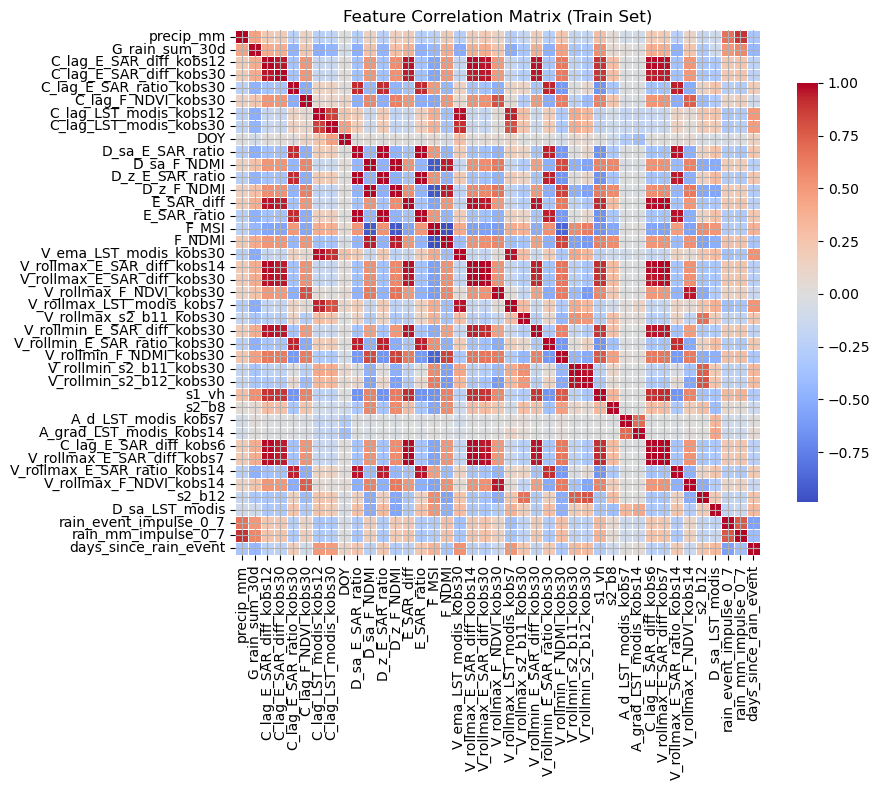

In [85]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

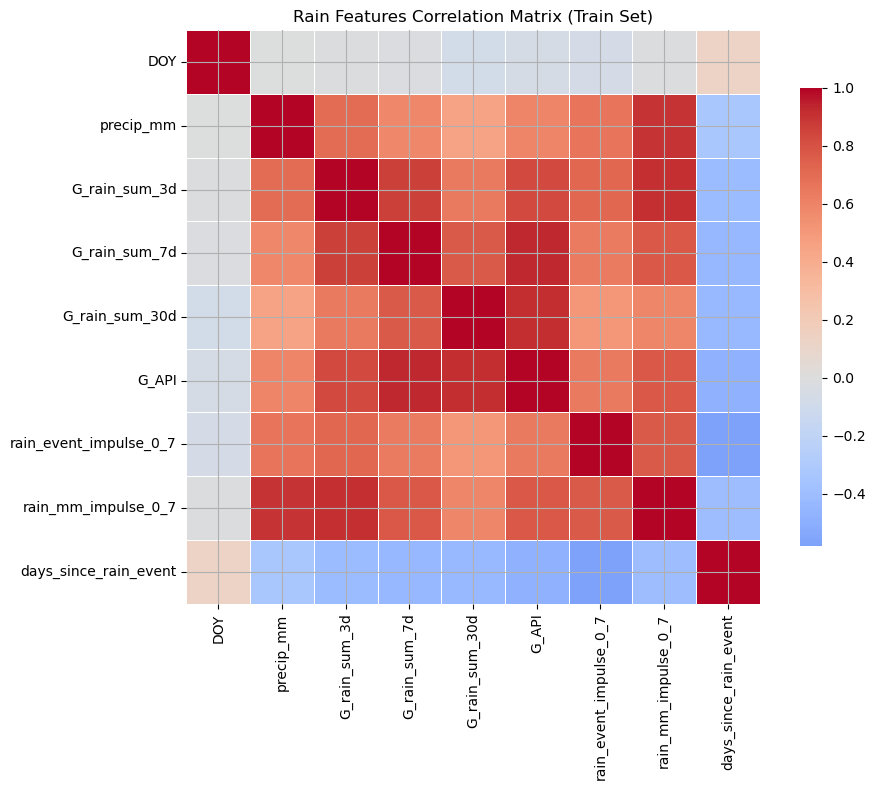

In [86]:
corr = Xr_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Rain Features Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [92]:
MODEL_CONFIG = {
    "objective":        "reg:squarederror",
    "n_estimators":     500,          # upper bound, early stopping will cap it
    "max_depth":        5, # can try 6 with stronger regularization
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "reg_alpha":        0.0,
    "reg_lambda":       1.0,
    "random_state":     SEED,
    "n_jobs":           -1,
}

RAIN_MODEL_CONFIG = {
    "objective":        "reg:squarederror",
    "random_state":     SEED,
    "n_jobs":           -1,
    "n_estimators":     600,
    "max_depth":        3,              # shallow on purpose
    "learning_rate":    0.05,
    "subsample":        0.9,
    "colsample_bytree": 0.9,
    "min_child_weight": 10,
    "reg_alpha":        0.0,
    "reg_lambda":       1.0,
}

print("MODEL_CONFIG:")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

print("\n---\n")

print("RAIN_MODEL_CONFIG:")
for k, v in RAIN_MODEL_CONFIG.items():
    print(f"  {k}: {v}")

MODEL_CONFIG:
  objective: reg:squarederror
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.0
  reg_lambda: 1.0
  random_state: 42
  n_jobs: -1

---

RAIN_MODEL_CONFIG:
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1
  n_estimators: 600
  max_depth: 3
  learning_rate: 0.05
  subsample: 0.9
  colsample_bytree: 0.9
  min_child_weight: 10
  reg_alpha: 0.0
  reg_lambda: 1.0


In [94]:
model = XGBRegressor(**MODEL_CONFIG)
print(model)

print("\n---\n")

rain_model = XGBRegressor(**RAIN_MODEL_CONFIG)
print(rain_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

---

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, fea

## 7. Training Loop

### 7.1 Fit Model

In [118]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

print("\n---\n")

rain_model.fit(
    Xr_train, yr_train,
    eval_set=[(Xr_train, yr_train), (Xr_val, yr_val)],
    verbose=50,
)

[0]	validation_0-rmse:0.09851	validation_1-rmse:0.09787
[50]	validation_0-rmse:0.03409	validation_1-rmse:0.04509
[100]	validation_0-rmse:0.02814	validation_1-rmse:0.04538
[150]	validation_0-rmse:0.02546	validation_1-rmse:0.04539
[200]	validation_0-rmse:0.02329	validation_1-rmse:0.04568
[250]	validation_0-rmse:0.02148	validation_1-rmse:0.04585
[300]	validation_0-rmse:0.01993	validation_1-rmse:0.04586
[350]	validation_0-rmse:0.01864	validation_1-rmse:0.04602
[400]	validation_0-rmse:0.01748	validation_1-rmse:0.04615
[450]	validation_0-rmse:0.01647	validation_1-rmse:0.04632
[499]	validation_0-rmse:0.01563	validation_1-rmse:0.04644

---

[0]	validation_0-rmse:0.09958	validation_1-rmse:0.09866
[50]	validation_0-rmse:0.05701	validation_1-rmse:0.04998
[100]	validation_0-rmse:0.05419	validation_1-rmse:0.04818
[150]	validation_0-rmse:0.05311	validation_1-rmse:0.04808
[200]	validation_0-rmse:0.05233	validation_1-rmse:0.04796
[250]	validation_0-rmse:0.05176	validation_1-rmse:0.04803
[300]	validati

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 7.2 Predictions

In [98]:
yhat_train = model.predict(X_train)
yhat_val   = model.predict(X_val)
yhat_test  = model.predict(X_test)

print("Predictions generated")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

Predictions generated
  yhat_train: (13661,)
  yhat_val:   (2919,)
  yhat_test:  (2659,)


In [120]:
yhat_rain_train = rain_model.predict(Xr_train)
yhat_rain_val   = rain_model.predict(Xr_val)
yhat_rain_test  = rain_model.predict(Xr_test)

r_train = yr_train - yhat_rain_train
r_val   = yr_val   - yhat_rain_val
r_test  = yr_test  - yhat_rain_test


In [121]:
print("Rain model predictions:")
print("  train:", yhat_rain_train.shape)
print("  val:  ", yhat_rain_val.shape)
print("  test: ", yhat_rain_test.shape)

Rain model predictions:
  train: (13661,)
  val:   (2919,)
  test:  (2659,)


In [122]:
print("Residual stats (train):")
print(pd.Series(r_train).describe())

Residual stats (train):
count    13661.000000
mean         0.000028
std          0.048974
min         -0.170282
25%         -0.029813
50%         -0.000406
75%          0.029128
max          0.223378
dtype: float64


### 7.3 Metrics

In [100]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

results = pd.DataFrame([
    metrics_block("train", y_train, yhat_train),
    metrics_block("val",   y_val,   yhat_val),
    metrics_block("test",  y_test,  yhat_test),
])

results

,split,MAE,RMSE,R2
0,train,0.011103,0.015629,0.976813
1,val,0.035866,0.046442,0.787377
2,test,0.042880,0.055056,0.671544


In [123]:
def eval_model(model, X, y):
    yhat = model.predict(X)
    return {
        "R2": float(r2_score(y, yhat)),
        "MAE": float(mean_absolute_error(y, yhat)),
        "RMSE": float(rmse(y, yhat)),
        "bias": float((y - yhat).mean()),
    }

print("\nRain-only ShallowXGB:")
print("  train:", eval_model(rain_model, Xr_train, yr_train))
print("  val:  ", eval_model(rain_model, Xr_val,   yr_val))
print("  test: ", eval_model(rain_model, Xr_test,  yr_test))


Rain-only ShallowXGB:
  train: {'R2': 0.7723446332067869, 'MAE': 0.03747355277064432, 'RMSE': 0.04897222566501248, 'bias': 2.804307320818188e-05}
  val:   {'R2': 0.770475184855402, 'MAE': 0.03716639613944931, 'RMSE': 0.04825278592851526, 'bias': 0.017824989232095228}
  test:  {'R2': 0.7597276001618116, 'MAE': 0.03514535219102661, 'RMSE': 0.047088579809233096, 'bias': 0.008381850069303988}


In [106]:
imp = rain_model.feature_importances_

coef_df = pd.DataFrame({
    "feature": RAIN_FEATURES,
    "importance": imp,
}).sort_values("importance", ascending=False)

coef_df

,feature,importance
5,G_API,0.493767
0,DOY,0.242528
4,G_rain_sum_30d,0.098162
2,G_rain_sum_3d,0.039254
6,rain_event_impulse_0_7,0.033174
8,days_since_rain_event,0.032384
3,G_rain_sum_7d,0.027362
1,precip_mm,0.017178
7,rain_mm_impulse_0_7,0.016191


### 7.4 Diagnostics

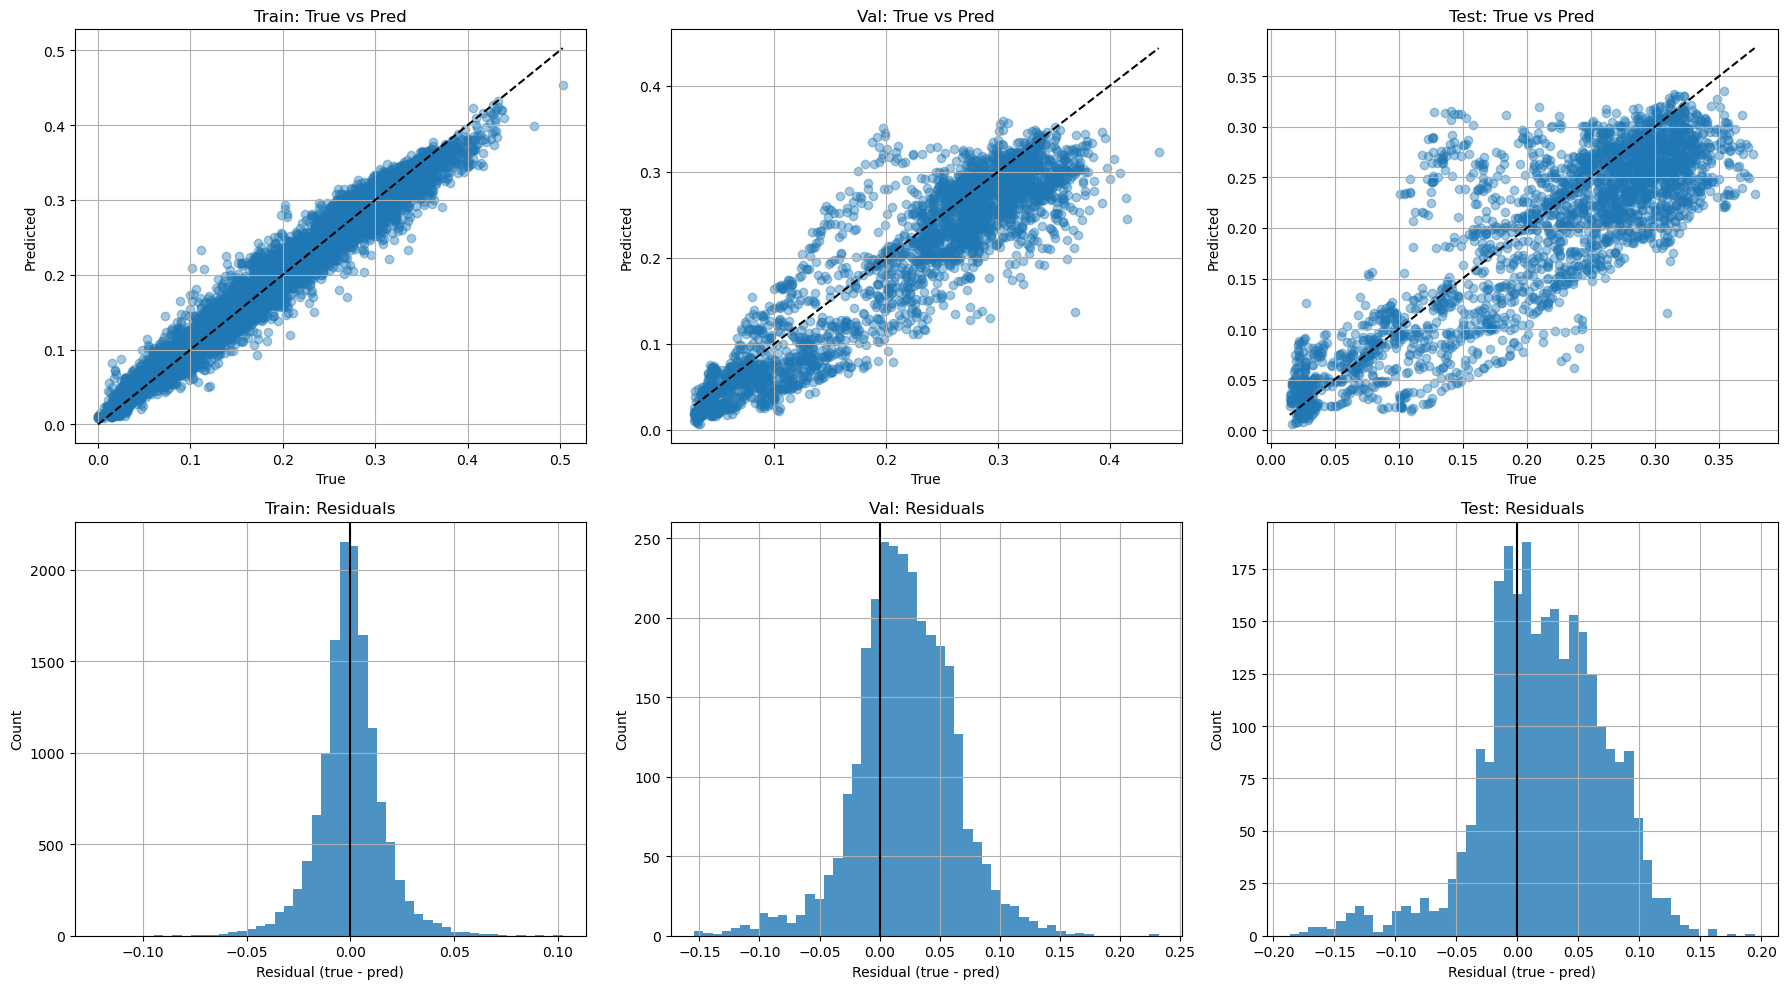

In [125]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test,  "Test: Residuals")

plt.tight_layout()
plt.show()

### 7.5 Feature Importance

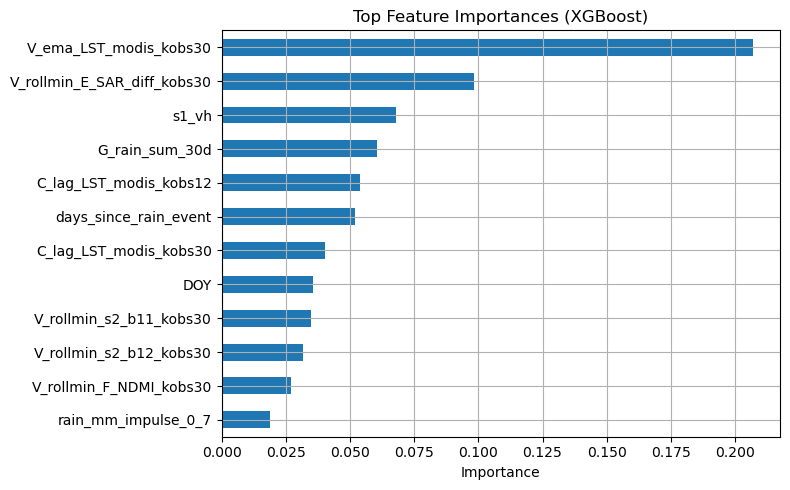

V_ema_LST_modis_kobs30          0.207186
V_rollmin_E_SAR_diff_kobs30     0.098127
s1_vh                           0.068102
G_rain_sum_30d                  0.060476
C_lag_LST_modis_kobs12          0.053748
days_since_rain_event           0.051781
C_lag_LST_modis_kobs30          0.040282
DOY                             0.035664
V_rollmin_s2_b11_kobs30         0.034733
V_rollmin_s2_b12_kobs30         0.031660
V_rollmin_F_NDMI_kobs30         0.027106
rain_mm_impulse_0_7             0.018964
rain_event_impulse_0_7          0.017626
E_SAR_diff                      0.017015
V_rollmax_E_SAR_diff_kobs7      0.016556
V_rollmax_E_SAR_diff_kobs14     0.016452
E_SAR_ratio                     0.015116
D_z_F_NDMI                      0.014033
V_rollmax_E_SAR_ratio_kobs14    0.012468
D_sa_F_NDMI                     0.011725
D_z_E_SAR_ratio                 0.011052
V_rollmax_F_NDVI_kobs30         0.010834
V_rollmax_LST_modis_kobs7       0.010704
F_NDMI                          0.010658
V_rollmin_E_SAR_

In [126]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

### 7.5 Bias

In [127]:
print("VAL residual mean: ", float((y_val.values - yhat_val).mean()))
print("TEST residual mean:", float((y_test.values - yhat_test).mean()))
print("VAL pred range:    ", float(yhat_val.min()), "-->", float(yhat_val.max()))
print("TEST pred range:   ", float(yhat_test.min()), "-->", float(yhat_test.max()))

VAL residual mean:  0.021495016501686188
TEST residual mean: 0.021190138887255357
VAL pred range:     0.006226351950317621 --> 0.3587266504764557
TEST pred range:    0.00560277933254838 --> 0.3353191912174225


## 8. Notes & Experiments

Using the predictions from the rain model as a new feature

In [ ]:
# Version 1

Xr_train = train_df[RAIN_FEATURES].copy()
Xr_val   = val_df[RAIN_FEATURES].copy()
Xr_test  = test_df[RAIN_FEATURES].copy()

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df["rain_pred"] = rain_model.predict(Xr_train)
val_df["rain_pred"]   = rain_model.predict(Xr_val)
test_df["rain_pred"]  = rain_model.predict(Xr_test)

In [142]:
# Version 2

RAW_RAIN = set(RAIN_FEATURES)
FEATURES_NO_RAW_RAIN = [f for f in FEATURE_COLS if f not in RAW_RAIN]

FULL_FEATURES_V2 = FEATURES_NO_RAW_RAIN + ["rain_pred"]

X_train_v2 = train_df[FULL_FEATURES_V2]
X_val_v2   = val_df[FULL_FEATURES_V2]
X_test_v2  = test_df[FULL_FEATURES_V2]

In [141]:
FULL_FEATURES_WITH_BACKBONE = FEATURE_COLS.copy()
if "rain_pred" not in FULL_FEATURES_WITH_BACKBONE:
    FULL_FEATURES_WITH_BACKBONE.append("rain_pred")

X_train_bb = train_df[FULL_FEATURES_WITH_BACKBONE].copy()
X_val_bb   = val_df[FULL_FEATURES_WITH_BACKBONE].copy()
X_test_bb  = test_df[FULL_FEATURES_WITH_BACKBONE].copy()

y_train = train_df[TARGET_COL].values
y_val   = val_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values

In [143]:
MODEL_CONFIG_FULL = { # from results_jakob.md
  "objective": "reg:squarederror",
  "random_state": SEED,
  "n_jobs": -1,
  "tree_method": "hist",

  "subsample": 0.9,
  "colsample_bytree": 0.75,

  "reg_lambda": 2.0,
  "reg_alpha": 0.05,

  "n_estimators": 4000,
  "learning_rate": 0.05,
  "max_depth": 7,
  "min_child_weight": 3,
  "gamma": 0.0,
}

In [144]:
main_model = XGBRegressor(**MODEL_CONFIG_FULL)
main_model.fit(
    X_train_bb, y_train,
    eval_set=[(X_train_bb, y_train), (X_val_bb, y_val)],
    verbose=50,
)

yhat_test = main_model.predict(X_test_bb)

[0]	validation_0-rmse:0.09814	validation_1-rmse:0.09787
[50]	validation_0-rmse:0.02402	validation_1-rmse:0.04579
[100]	validation_0-rmse:0.01751	validation_1-rmse:0.04505
[150]	validation_0-rmse:0.01530	validation_1-rmse:0.04504
[200]	validation_0-rmse:0.01359	validation_1-rmse:0.04487
[250]	validation_0-rmse:0.01222	validation_1-rmse:0.04473
[300]	validation_0-rmse:0.01108	validation_1-rmse:0.04461
[350]	validation_0-rmse:0.01011	validation_1-rmse:0.04453
[400]	validation_0-rmse:0.00933	validation_1-rmse:0.04442
[450]	validation_0-rmse:0.00869	validation_1-rmse:0.04436
[500]	validation_0-rmse:0.00814	validation_1-rmse:0.04428
[550]	validation_0-rmse:0.00767	validation_1-rmse:0.04426
[600]	validation_0-rmse:0.00724	validation_1-rmse:0.04423
[650]	validation_0-rmse:0.00687	validation_1-rmse:0.04423
[700]	validation_0-rmse:0.00653	validation_1-rmse:0.04419
[750]	validation_0-rmse:0.00622	validation_1-rmse:0.04415
[800]	validation_0-rmse:0.00596	validation_1-rmse:0.04414
[850]	validation_

In [147]:
main_model = XGBRegressor(**MODEL_CONFIG_FULL)
main_model.fit(
    X_train_v2, y_train,
    eval_set=[(X_train_v2, y_train), (X_val_v2, y_val)],
    verbose=50,
)

yhat_test_v2 = main_model.predict(X_test_v2)

[0]	validation_0-rmse:0.09819	validation_1-rmse:0.09784
[50]	validation_0-rmse:0.02549	validation_1-rmse:0.04821
[100]	validation_0-rmse:0.01932	validation_1-rmse:0.04783
[150]	validation_0-rmse:0.01712	validation_1-rmse:0.04780
[200]	validation_0-rmse:0.01546	validation_1-rmse:0.04783
[250]	validation_0-rmse:0.01412	validation_1-rmse:0.04770
[300]	validation_0-rmse:0.01311	validation_1-rmse:0.04770
[350]	validation_0-rmse:0.01229	validation_1-rmse:0.04772
[400]	validation_0-rmse:0.01157	validation_1-rmse:0.04765
[450]	validation_0-rmse:0.01098	validation_1-rmse:0.04768
[500]	validation_0-rmse:0.01042	validation_1-rmse:0.04761
[550]	validation_0-rmse:0.01000	validation_1-rmse:0.04758
[600]	validation_0-rmse:0.00962	validation_1-rmse:0.04757
[650]	validation_0-rmse:0.00928	validation_1-rmse:0.04752
[700]	validation_0-rmse:0.00896	validation_1-rmse:0.04749
[750]	validation_0-rmse:0.00870	validation_1-rmse:0.04750
[800]	validation_0-rmse:0.00845	validation_1-rmse:0.04746
[850]	validation_

In [148]:
def eval_preds(y, yhat):
    return {
        "R2": float(r2_score(y, yhat)),
        "MAE": float(mean_absolute_error(y, yhat)),
        "RMSE": float(rmse(y, yhat)),
        "bias": float((y - yhat).mean()),
    }

In [150]:
print("Main model with rain backbone feature:")
print("  train:", eval_preds(y_train, main_model.predict(X_train_v2)))
print("  val:  ", eval_preds(y_val,   main_model.predict(X_val_v2)))
print("  test: ", eval_preds(y_test,  yhat_test))

Main model with rain backbone feature:
  train: {'R2': 0.9980495063788851, 'MAE': 0.003077430084929642, 'RMSE': 0.0045329733185766295, 'bias': -2.0303929433204012e-06}
  val:   {'R2': 0.7808096498448598, 'MAE': 0.03603585296268433, 'RMSE': 0.04715397239976307, 'bias': 0.020987242237560426}
  test:  {'R2': 0.6846874723535661, 'MAE': 0.04149338722531062, 'RMSE': 0.05394289647279325, 'bias': 0.018085656819626234}


In [152]:
imp = pd.Series(main_model.feature_importances_, index=FULL_FEATURES_V2).sort_values(ascending=False)
print("Top 15 features:\n", imp.head(15))
print("\nrain_pred importance:", float(imp.get("rain_pred", -1)))

Top 15 features:
 V_rollmin_E_SAR_diff_kobs30     0.219350
rain_pred                       0.192883
V_rollmin_E_SAR_ratio_kobs30    0.060117
V_rollmin_s2_b12_kobs30         0.041180
V_rollmin_s2_b11_kobs30         0.038187
V_rollmax_F_NDVI_kobs30         0.037161
V_rollmax_E_SAR_diff_kobs30     0.030944
V_rollmax_E_SAR_diff_kobs14     0.030506
V_rollmax_s2_b11_kobs30         0.026094
V_rollmin_F_NDMI_kobs30         0.024730
s1_vh                           0.022915
V_ema_LST_modis_kobs30          0.021983
V_rollmax_E_SAR_ratio_kobs14    0.020098
C_lag_E_SAR_ratio_kobs30        0.018261
D_sa_E_SAR_ratio                0.017599
dtype: float32

rain_pred importance: 0.1928831785917282


## 9. Save Artifacts

In [32]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v8/v8.1/mdr_ts_v8_1_20260121_105425


In [33]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v8/v8.1/mdr_ts_v8_1_20260121_105425/model.json


In [34]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v8/v8.1/mdr_ts_v8_1_20260121_105425/run_metadata.json


In [35]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v8/v8.1/mdr_ts_v8_1_20260121_105425/metrics.csv


In [36]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v8/v8.1/mdr_ts_v8_1_20260121_105425/feature_importance.csv


In [37]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

---

_Jakob Balkovec_